In [ ]:
!pip install openpyxl

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Pharmaceutical Supply Chain Optimization.xlsx to Pharmaceutical Supply Chain Optimization (2).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

print(df.head())

           Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy
0     Metformin             7750                 4753             Monthly
1    Lisinopril             5136                 9965           Quarterly
2     Metformin             3183                 2933             Monthly
3       Insulin             2332                 3927             Monthly
4  Atorvastatin             3522                 6812             Monthly


In [ ]:
df = pd.read_excel(
    "Pharmaceutical Supply Chain Optimization.xlsx",
    engine='openpyxl'
)

In [ ]:
df.to_csv("pharma.csv", index=False)

In [ ]:
df = pd.read_csv("pharma.csv")

In [ ]:
df

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,Metformin,7750,4753,Monthly
1,Lisinopril,5136,9965,Quarterly
2,Metformin,3183,2933,Monthly
3,Insulin,2332,3927,Monthly
4,Atorvastatin,3522,6812,Monthly
...,...,...,...,...
99995,Metformin,7635,7794,Weekly
99996,Atorvastatin,8438,7308,Monthly
99997,Metformin,4950,3445,Quarterly
99998,Atorvastatin,4672,5278,Monthly


In [ ]:
# First 5 Rows
print(df.head())

           Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy
0     Metformin             7750                 4753             Monthly
1    Lisinopril             5136                 9965           Quarterly
2     Metformin             3183                 2933             Monthly
3       Insulin             2332                 3927             Monthly
4  Atorvastatin             3522                 6812             Monthly


In [ ]:
# Dataset Shape
print(df.shape)

(100000, 4)


In [ ]:
# Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB
None


In [ ]:
# Data Types
print(df.dtypes)

Drug                   object
Demand_Forecast         int64
Optimal_Stock_Level     int64
Restocking_Strategy    object
dtype: object


In [ ]:
# Statistical Summary
print(df.describe())

       Demand_Forecast  Optimal_Stock_Level
count    100000.000000        100000.000000
mean       5489.372180          6270.155320
std        2597.544993          2744.393068
min        1000.000000          1500.000000
25%        3243.000000          3899.750000
50%        5487.000000          6278.000000
75%        7738.000000          8660.000000
max        9999.000000         10999.000000


Question 2: Handle Missing Values and Outliers

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Check Missing Values
print(df.isnull().sum())


Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64


In [ ]:
# Fill Missing Values
df = df.fillna(df.median(numeric_only=True))

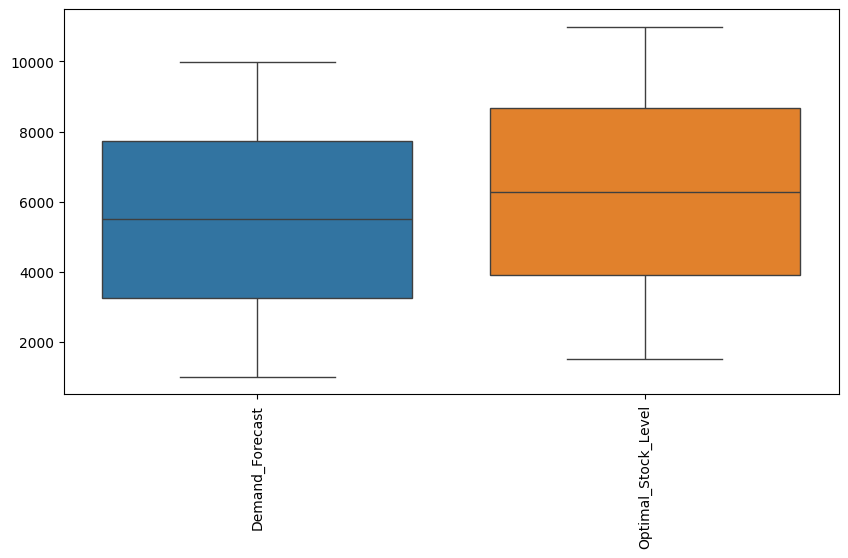

In [ ]:
# Boxplot for Outliers
plt.figure(figsize=(10,5))

sns.boxplot(data=df.select_dtypes(include=['int64','float64']))

plt.xticks(rotation=90)

plt.show()

Question 3: Perform EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

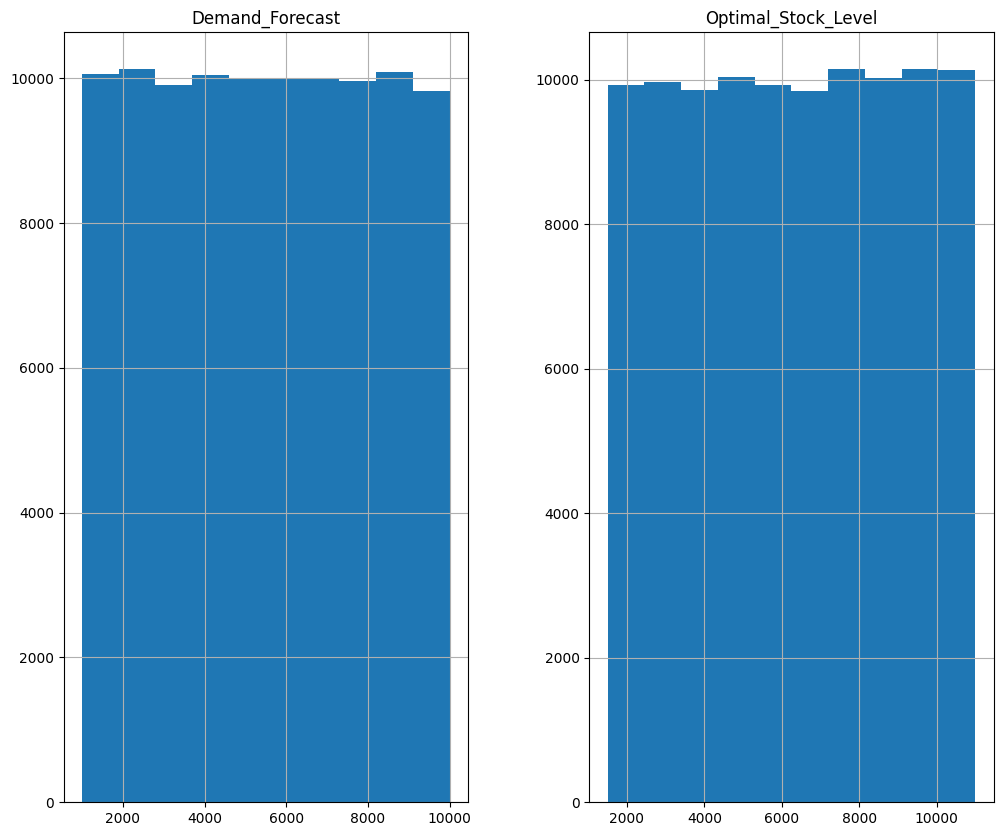

In [ ]:
# Distribution Plot
df.hist(figsize=(12,10))

plt.show()

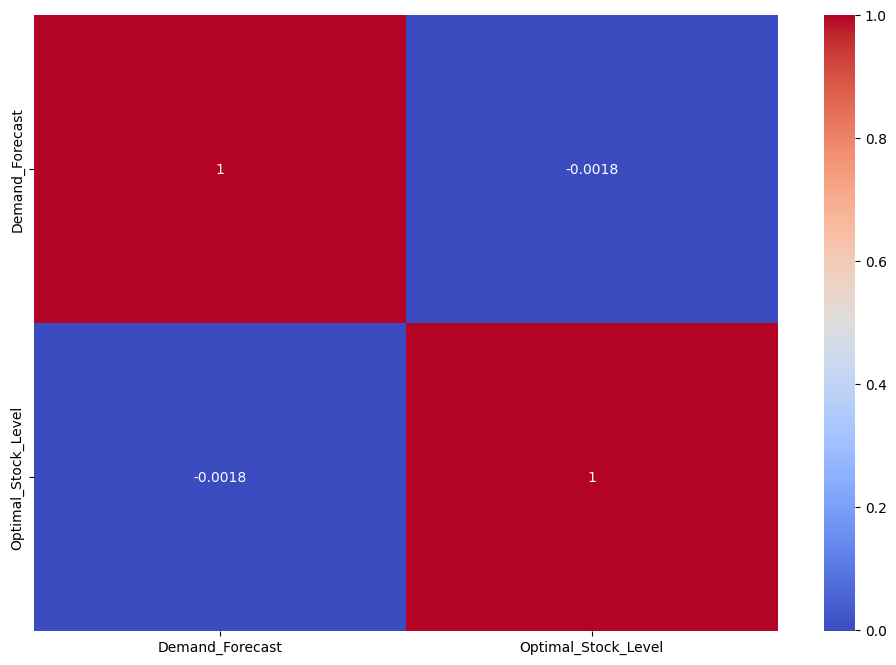

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True
)

plt.show()

Question 4: Feature Engineering

In [ ]:
# 1. Stock Difference
df['Stock_Difference'] = (
    df['Optimal_Stock_Level'] -
    df['Demand_Forecast']
)


In [ ]:
# 2. Demand Category
df['Demand_Category'] = pd.cut(
    df['Demand_Forecast'],
    bins=[0, 100, 500, 1000],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
# 3. Stock Status
df['Stock_Status'] = df['Stock_Difference'].apply(
    lambda x: 'Need Restock' if x < 0 else 'Sufficient'
)


In [ ]:
# Show Updated Dataset
print(df.head())

           Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy  \
0     Metformin             7750                 4753             Monthly   
1    Lisinopril             5136                 9965           Quarterly   
2     Metformin             3183                 2933             Monthly   
3       Insulin             2332                 3927             Monthly   
4  Atorvastatin             3522                 6812             Monthly   

   Stock_Difference Demand_Category  Stock_Status  
0             -2997             NaN  Need Restock  
1              4829             NaN    Sufficient  
2              -250             NaN  Need Restock  
3              1595             NaN    Sufficient  
4              3290             NaN    Sufficient  


In [ ]:
# Check Columns
print(df.columns)

Index(['Drug', 'Demand_Forecast', 'Optimal_Stock_Level', 'Restocking_Strategy',
       'Stock_Difference', 'Demand_Category', 'Stock_Status'],
      dtype='object')


Question 5: Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Drug  Demand_Forecast  Optimal_Stock_Level  Restocking_Strategy  \
0     3             7750                 4753                    0   
1     2             5136                 9965                    1   
2     3             3183                 2933                    0   
3     1             2332                 3927                    0   
4     0             3522                 6812                    0   

   Stock_Difference Demand_Category  Stock_Status  
0             -2997             NaN             0  
1              4829             NaN             1  
2              -250             NaN             0  
3              1595             NaN             1  
4              3290             NaN             1  


Question 6: Build Linear Regression Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
# Encode Categorical Columns
le = LabelEncoder()


In [ ]:
df['Drug'] = le.fit_transform(df['Drug'])
df['Restocking_Strategy'] = le.fit_transform(df['Restocking_Strategy'])

In [ ]:
# Features and Target
X = df[['Drug', 'Demand_Forecast']]
y = df['Optimal_Stock_Level']

In [ ]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train Model
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Train Model
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediction
y_pred = lr.predict(X_test)



In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression RMSE :", rmse)

Linear Regression RMSE : 2738.227013994203


Question 7: Build Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Prediction
y_pred = rf.predict(X_test)

In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest RMSE :", rmse)

Random Forest RMSE : 3165.9930598685833


Question 8: Compare with Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Train Model
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# Prediction
y_pred = gb.predict(X_test)


In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Gradient Boosting RMSE :", rmse)

Gradient Boosting RMSE : 2739.893604745623


Question 9: Hyperparameter Tuning using GridSearchCV

In [ ]:
# Parameter Grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

In [ ]:
# GridSearchCV
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

In [ ]:
# Train
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
# Best Parameters
print("Best Parameters :", grid.best_params_)

Best Parameters : {'max_depth': 5, 'n_estimators': 100}


In [ ]:
# Best Model
best_model = grid.best_estimator_

Question 10: Evaluate Final Model with RMSE and Cross Validation

In [ ]:
import numpy as np

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV

In [ ]:
# Prediction
y_pred = best_model.predict(X_test)

In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Final RMSE :", rmse)

Final RMSE : 3165.9930598685833


In [ ]:
# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

In [ ]:
# Convert to RMSE
cv_rmse = np.sqrt(-cv_scores)

print("Cross Validation RMSE Scores :")
print(cv_rmse)

print("Average RMSE :", cv_rmse.mean())

Cross Validation RMSE Scores :
[2737.32646364 2741.01872124 2749.13287008 2743.09008383 2752.81283016]
Average RMSE : 2744.6761937887923
